# Archived multi-mode molecular-vibration prototype

> **Archive warning:** this exploratory notebook combines H₂ reference electronic coefficients with three illustrative vibrational modes. It is not an ab-initio H₂O calculation and is retained only for provenance.


In [ ]:
from openfermion.ops import FermionOperator
from openfermion.transforms import bravyi_kitaev
from qutip import Qobj, tensor, basis, sesolve, expect, qeye, destroy
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

In [ ]:
# ===== 1. H₂ 参考系数的探索性电子哈密顿量（不是 H₂O 从头算积分） =====
fermionic_ham = FermionOperator()                       #初始化一个空的费米子哈密顿量
fermionic_ham += FermionOperator('', -0.81261)          #这是 常数项，代表核间排斥能 + 电子能的偏移项。
# 这些是单电子项（one-body terms).
# p^ p表示电子从轨道 p 湮灭并重新创建（等于存在于轨道 p 的概率).
# 系数是该轨道对应的能量，源自量子化学计算.
fermionic_ham += FermionOperator('0^ 0', -1.25248)
fermionic_ham += FermionOperator('1^ 1', -0.47595)
fermionic_ham += FermionOperator('2^ 2', -0.47595)
fermionic_ham += FermionOperator('3^ 3', -1.25248)
# 这些是双电子项（two-body terms），表示电子间库仑排斥.
# 格式 p^ q^ r s 代表：电子从 r 和 s 两个轨道中被湮灭，同时在 p 和 q 中被创建.
# 这是对电子间相互作用的建模，来源于积分项 ℎ_pqrs
fermionic_ham += FermionOperator('0^ 1^ 1 0', 0.67449)
fermionic_ham += FermionOperator('0^ 2^ 2 0', 0.66458)
fermionic_ham += FermionOperator('0^ 3^ 3 0', 0.18129)
fermionic_ham += FermionOperator('1^ 2^ 2 1', 0.18129)
fermionic_ham += FermionOperator('1^ 3^ 3 1', 0.66458)
fermionic_ham += FermionOperator('2^ 3^ 3 2', 0.67449)
# 这是交换项（exchange interaction），也属于双电子项，但构型不同,通常用于耦合两个 Slater 行列式之间的跃迁。
fermionic_ham += FermionOperator('0^ 1^ 2 3', 0.66347)
fermionic_ham += FermionOperator('3^ 2^ 1 0', 0.66347)

In [ ]:
# ===== 2. BK 映射 + 电子哈密顿量转为 Qobj =====
qubit_ham = bravyi_kitaev(fermionic_ham)
n_qubits = 4

def qubit_operator_to_qutip(qubit_op, n_qubits):           #把 OpenFermion 的 QubitOperator 转换成 QuTiP 的 Qobj 矩阵。
    
    pauli_map = {'X': Qobj([[0, 1], [1, 0]]),              #定义 2x2 的 Pauli 矩阵，用 QuTiP 的 Qobj 表示。
                 'Y': Qobj([[0, -1j], [1j, 0]]),
                 'Z': Qobj([[1, 0], [0, -1]]),
                 'I': Qobj([[1, 0], [0, 1]])}
    H = 0
    for term, coeff in qubit_op.terms.items():
        ops = [pauli_map['I']] * n_qubits                  #初始化为单位矩阵（I），把对应 qubit 替换为 X/Y/Z，准备张量积。
        for idx, op in term:
            ops[idx] = pauli_map[op]
        H += coeff * tensor(ops)                           #对每个项求张量积后乘系数，加到总哈密顿量上。
    return H

H_el = qubit_operator_to_qutip(qubit_ham, n_qubits)

#### 第二步想把前面手动构造的电子哈密顿量（fermionic_ham），先通过 Bravyi-Kitaev 映射 → 得到 qubit_ham（Pauli 算符组合），然后把它变成可用于模拟的 Qobj（矩阵表示）。准备好用于模拟电子部分动力学的矩阵表达。

In [ ]:
# ===== 3. 三模振动项构造（对应 v1, v2, v3） =====
n1, n2, n3 = 4, 4, 4                                          #每个振动模的能级截断维度（最多保留前 4 个 Fock 态）。简谐振子理论上能级无限大，这里为了可模拟，截断为 4。
w1, w2, w3 = 1.0, 0.7, 1.2                                    #每个振动模的频率（ω₁、ω₂、ω₃），单位一般是原子单位（a.u.）
a1, a2, a3 = destroy(n1), destroy(n2), destroy(n3)            #创建 3 个降阶算符 a（QuTiP 中的 destroy(n)），用来构造哈密顿量 𝐻=𝜔𝑎†𝑎
#构造 𝐻_vib=∑𝑖=1——3𝜔_𝑖𝑎_𝑖†𝑎_𝑖,使用 tensor 构建三个 Hilbert 空间张量积
H_vib = tensor(w1 * a1.dag() * a1, qeye(n2), qeye(n3)) + \
         tensor(qeye(n1), w2 * a2.dag() * a2, qeye(n3)) + \
         tensor(qeye(n1), qeye(n2), w3 * a3.dag() * a3)

H_vib_ext = tensor(qeye(2 ** n_qubits), H_vib)                #扩展到整个系统空间（电子空间 × 振动空间）,因为电子部分用了 n_qubits = 4 个 qubit（维度 16）,所以我们在整个 Hilbert 空间中构造 电子 + 振动模的组合系统.
H_vib_ext.dims = [[2]*n_qubits + [n1, n2, n3], [2]*n_qubits + [n1, n2, n3]]  #设置 Qobj 的维度，确保兼容 QuTiP 的张量积系统表示

#### 探索性三模简谐振子原型；该模型未使用 H₂O 的从头算电子积分，不应解释为定量 H₂O 模拟。

In [ ]:
# ===== 4. 构建耦合项 Z₀/Z₁/Z₂ 与 (a + a†) =====
g1, g2, g3 = 0.5, 0.3, 0.4                                                   #三个耦合强度参数 𝑔_𝑖
Z = Qobj([[1, 0], [0, -1]])                                                  #Z 是 Pauli-Z 算符，表示电子处于“在此轨道”或“不在”轨道的二值状态
# 构造 Z0 / Z1 / Z2 —— 每个Z对应不同量子比特
# Z被嵌入到第 0 / 1 / 3 个 qubit 的位置，其余填单位算符，构成在电子子空间上的 Z 投影。
Z0_base = tensor(Z, *[qeye(2)] * (n_qubits - 1))
Z1_base = tensor(qeye(2), Z, *[qeye(2)] * (n_qubits - 2))
Z2_base = tensor(*[qeye(2)] * (n_qubits - 1) + [Z])

# Broadcast Pauli Z to full space；广播 Z 到电子+振动模空间
# 将 Z 延展到完整 Hilbert 空间：电子 + 振动模的张量积结构。
Z0 = tensor(Z0_base, qeye(n1), qeye(n2), qeye(n3))
Z1 = tensor(Z1_base, qeye(n1), qeye(n2), qeye(n3))
Z2 = tensor(Z2_base, qeye(n1), qeye(n2), qeye(n3))

# Build a_i + a_i† with appropriate tensor shapes
# 分别构造每个模对应的 位置算符，用于耦合。注意张量积中，确保该振动模的那一项是非单位，其他是单位矩阵。
a_term1 = tensor(qeye(2 ** n_qubits), a1 + a1.dag(), qeye(n2), qeye(n3))
a_term2 = tensor(qeye(2 ** n_qubits), qeye(n1), a2 + a2.dag(), qeye(n3))
a_term3 = tensor(qeye(2 ** n_qubits), qeye(n1), qeye(n2), a3 + a3.dag())

# Broadcast dims to ensure consistent structure
# 这个很重要对齐维度（重要），手动设定 Qobj 的 .dims 属性，确保广播后结构一致（QuTiP 要求张量结构一致才能加乘）。
a_term1.dims = Z0.dims
a_term2.dims = Z1.dims
a_term3.dims = Z2.dims

H_int = g1 * Z0 * a_term1 + g2 * Z1 * a_term2 + g3 * Z2 * a_term3



#### $H_{\text{int}} = g_1 Z_0 (a_1 + a_1^\dagger) + g_2 Z_1 (a_2 + a_2^\dagger) + g_3 Z_2 (a_3 + a_3^\dagger)$
#### $Z_0,Z_1,Z_2$表示电子状态，每个qubit的Pauli-Z表示; $a + a\dagger$表示对应振动模的谐振子位置算符；$z_i*(a_i + a_i\dagger)$表示声子耦合模型

In [ ]:
# ===== 5. 构造总哈密顿量 H_tot =====
H_el_ext = tensor(H_el, qeye(n1), qeye(n2), qeye(n3))
H_el_ext.dims = [[2]*n_qubits + [n1, n2, n3], [2]*n_qubits + [n1, n2, n3]]
H_tot = H_el_ext + H_vib_ext + H_int

#### $H_{\text{tot}} = H_{\text{el}} \otimes I_{\text{vib}} + I_{\text{el}} \otimes H_{\text{vib}} + H_{\text{int}}$
#### 其中$H_{el}$:电子部分的哈密顿量;$H_{vib}:振动部分的哈密顿量$;$H_{int}:电子与振动之间的耦合项$;$I_{el}$,$I_vib$:分别是电子和振动部分的单位算符
#### 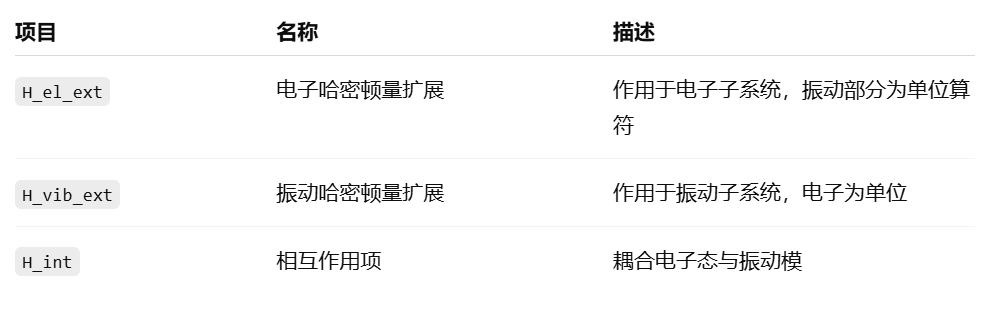

In [ ]:
# ===== 6. 初始态 =====
psi_el = tensor([basis(2, 0) for _ in range(n_qubits)])
psi_vib = tensor(basis(n1, 0), basis(n2, 0), basis(n3, 0))
psi0 = tensor(psi_el, psi_vib)

In [ ]:
# ===== 7. 动力学演化 =====
tlist = np.linspace(0, 25, 300)
result = sesolve(H_tot, psi0, tlist)

In [ ]:
# ===== 7. 观测一个振动模的电子响应，例如 Z0 期望值 =====
Z0_obs = Z0
z0_expect = expect(Z0_obs, result.states)

plt.plot(tlist, z0_expect)
plt.xlabel("Time")
plt.ylabel("⟨Z0⟩")
plt.title("H₂O Vibrational Coupling: Z0 Expectation")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
Z1_obs = Z1
z1_expect = expect(Z1_obs, result.states)

plt.plot(tlist, z1_expect)
plt.xlabel("Time")
plt.ylabel("⟨Z1⟩")
plt.title("H₂O Vibrational Coupling: Z1 Expectation")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
Z2_obs = Z2
z2_expect = expect(Z2_obs, result.states)

plt.plot(tlist, z2_expect)
plt.xlabel("Time")
plt.ylabel("⟨Z2⟩")
plt.title("H₂O Vibrational Coupling: Z2 Expectation")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# ===== 7. 动力学演化与观测 =====
tlist = np.linspace(0, 25, 300)
result = sesolve(H_tot, psi0, tlist)
a1_op = tensor(qeye(2**n_qubits), a1 + a1.dag(), qeye(n2), qeye(n3))
a1_op.dims = [[2]*n_qubits + [n1, n2, n3], [2]*n_qubits + [n1, n2, n3]]

a2_op = tensor(qeye(2**n_qubits), qeye(n1), a2 + a2.dag(), qeye(n3))
a2_op.dims = [[2]*n_qubits + [n1, n2, n3], [2]*n_qubits + [n1, n2, n3]]

a3_op = tensor(qeye(2**n_qubits), qeye(n1), qeye(n2), a3 + a3.dag())
a3_op.dims = [[2]*n_qubits + [n1, n2, n3], [2]*n_qubits + [n1, n2, n3]]

a1_expect = expect(a1_op, result.states)
a2_expect = expect(a2_op, result.states)
a3_expect = expect(a3_op, result.states)


In [ ]:
# ===== 8. 可视化频率和耦合强度 =====
freqs = [w1, w2, w3]
couplings = [g1, g2, g3]
labels = ["v₁ (Symmetric Stretch)", "v₂ (Bending)", "v₃ (Asymmetric Stretch)"]

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.bar(labels, freqs)
plt.title("Vibrational Mode Frequencies")
plt.ylabel("Frequency (a.u.)")
plt.xticks(rotation=15)

plt.subplot(1, 2, 2)
plt.bar(labels, couplings)
plt.title("Electron-Vibronic Couplings")
plt.ylabel("Coupling Strength g")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()


In [ ]:
# ===== 9. 动画输出展示振动模式动态 =====
fig, ax = plt.subplots(figsize=(5, 4))
line1, = ax.plot([], [], 'r-', lw=2, label='v₁')
line2, = ax.plot([], [], 'b-', lw=2, label='v₂')
line3, = ax.plot([], [], 'g-', lw=2, label='v₃')
ax.set_xlim(-1, 1)
ax.set_ylim(-2, 2)
ax.legend()
ax.set_title("Vibrational Modes Animation")
ax.set_xlabel("Position displacement x")  # x 轴表示位置偏移
ax.set_ylabel("Amplitude")                 # y 轴表示振动幅度
x = np.linspace(-1, 1, 100)

def init():
    line1.set_data([], [])
    line2.set_data([], [])
    line3.set_data([], [])
    return line1, line2, line3

def animate(i):
    t = tlist[i]
    line1.set_data(x, np.sin(2 * np.pi * w1 * t) * np.exp(-x**2))
    line2.set_data(x, np.sin(2 * np.pi * w2 * t + np.pi/2) * np.exp(-x**2))
    line3.set_data(x, np.sin(2 * np.pi * w3 * t + np.pi) * np.exp(-x**2))
    return line1, line2, line3

ani = animation.FuncAnimation(fig, animate, init_func=init, frames=len(tlist), interval=50, blit=True)

# 输出 HTML5 动图
HTML(ani.to_jshtml())